In [1]:
import os 
print(os.getcwd())

/Users/lizyeo/DSI/team_project


In [2]:
os.chdir('/Users/lizyeo/DSI/team_project/data')

In [3]:
print(os.getcwd())

/Users/lizyeo/DSI/team_project/data


In [4]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
import statsmodels.api as sm
from ISLP.models import (ModelSpec as MS,
                         summarize)
from ISLP import confusion_table
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv("../data/creditcard.csv")

In [5]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [6]:
# display the columns
df.columns

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='object')

In [7]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [8]:
#Check for null values, no null values
df.isnull().sum().max()

0

In [9]:
df['Class'].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

In [10]:
# % of non-fraud cases
round(df['Class'].value_counts()[0]/len(df)*100,2)

99.83

In [11]:
# % of fraud cases
round(df['Class'].value_counts()[1]/len(df)*100,2)

0.17

Our dataset is highly imbalanced. 99.83% of the dataset are non-fraud and only 0.17% are fraud.

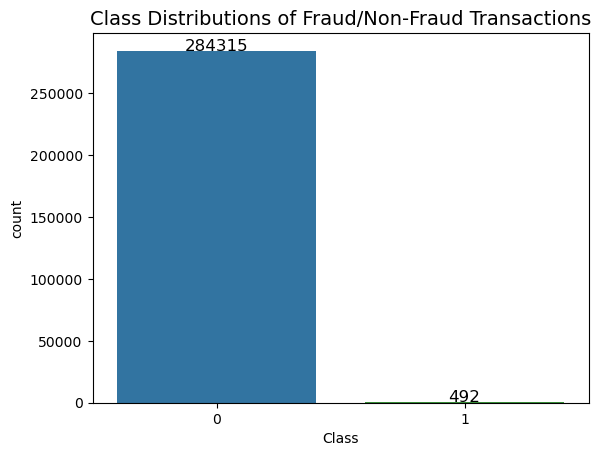

In [12]:
colors = ["#1f77b4","#2ca02c"]
sns.countplot(x='Class',data= df, palette= colors)
plt.title('Class Distributions of Fraud/Non-Fraud Transactions', fontsize=14)

# Add data labels
for p in plt.gca().patches:
    plt.text(p.get_x()+p.get_width()/2., p.get_height()+5,
             f'{int(p.get_height())}', ha='center', fontsize=12)
    
plt.show()

In [13]:
df['Amount'].values

array([149.62,   2.69, 378.66, ...,  67.88,  10.  , 217.  ])

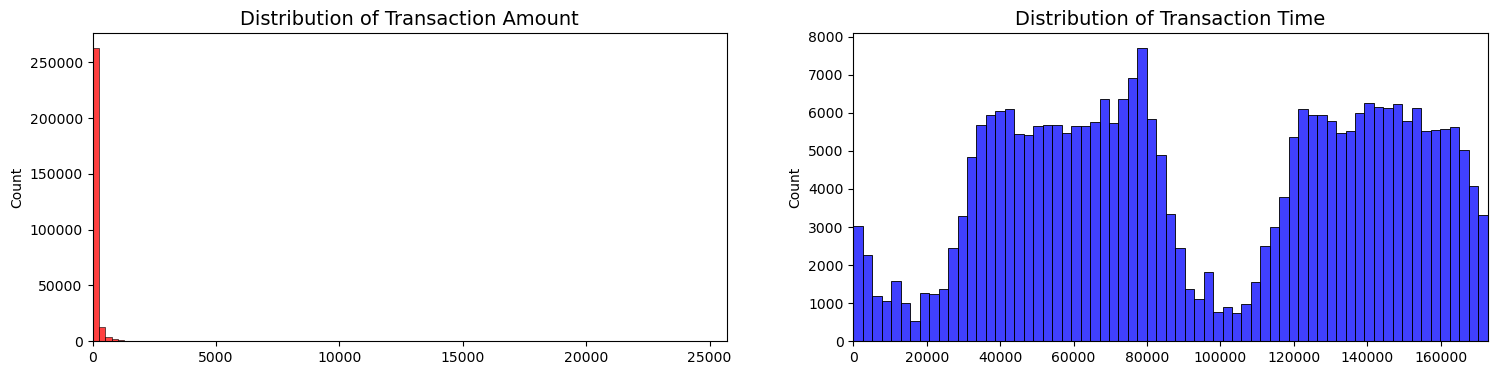

In [14]:
# Plot the distribution

fig, ax = plt.subplots(1,2, figsize=(18,4)) #create 2 subplots

amount = df['Amount'].values
time = df['Time'].values

sns.histplot(amount, ax=ax[0], color='r', bins=100)
ax[0].set_title('Distribution of Transaction Amount', fontsize=14)
ax[0].set_xlim([min(amount),max(amount)])

sns.histplot(time, ax=ax[1], color='b')
ax[1].set_title('Distribution of Transaction Time', fontsize=14)
ax[1].set_xlim([min(time),max(time)])

plt.show()

In [15]:
#Display the Transaction Amount distribution in details, majority of the transactions are between 0-200

bins = [0, 100, 200, 300, 400, 500, 600, 700, 800, 900, 1000, df['Amount'].max()]
amount_binned = pd.cut(df['Amount'], bins=bins)

amount_distribution = amount_binned.value_counts().sort_index()

amount_distribution_df = amount_distribution.reset_index()
amount_distribution_df.columns = ['Transaction Amount Range','No. of Transactions']

amount_distribution_df

,Transaction Amount Range,No. of Transactions
0,"(0.0, 100.0]",226474
1,"(100.0, 200.0]",27671
2,"(200.0, 300.0]",10776
3,"(300.0, 400.0]",5537
4,"(400.0, 500.0]",3382
5,"(500.0, 600.0]",2155
6,"(600.0, 700.0]",1435
7,"(700.0, 800.0]",1081
8,"(800.0, 900.0]",823
9,"(900.0, 1000.0]",708


In [17]:
# Drop duplicates in the data as it can skew the results later
# Remove duplicates
df_no_dup = df.drop_duplicates().copy()

# Verify if duplicates are removed
print(f"Data shape after removing duplicates: {df_no_dup.shape}")


Data shape after removing duplicates: (283726, 31)


In [18]:
# Data shape before dropping duplicates
df.shape

(284807, 31)

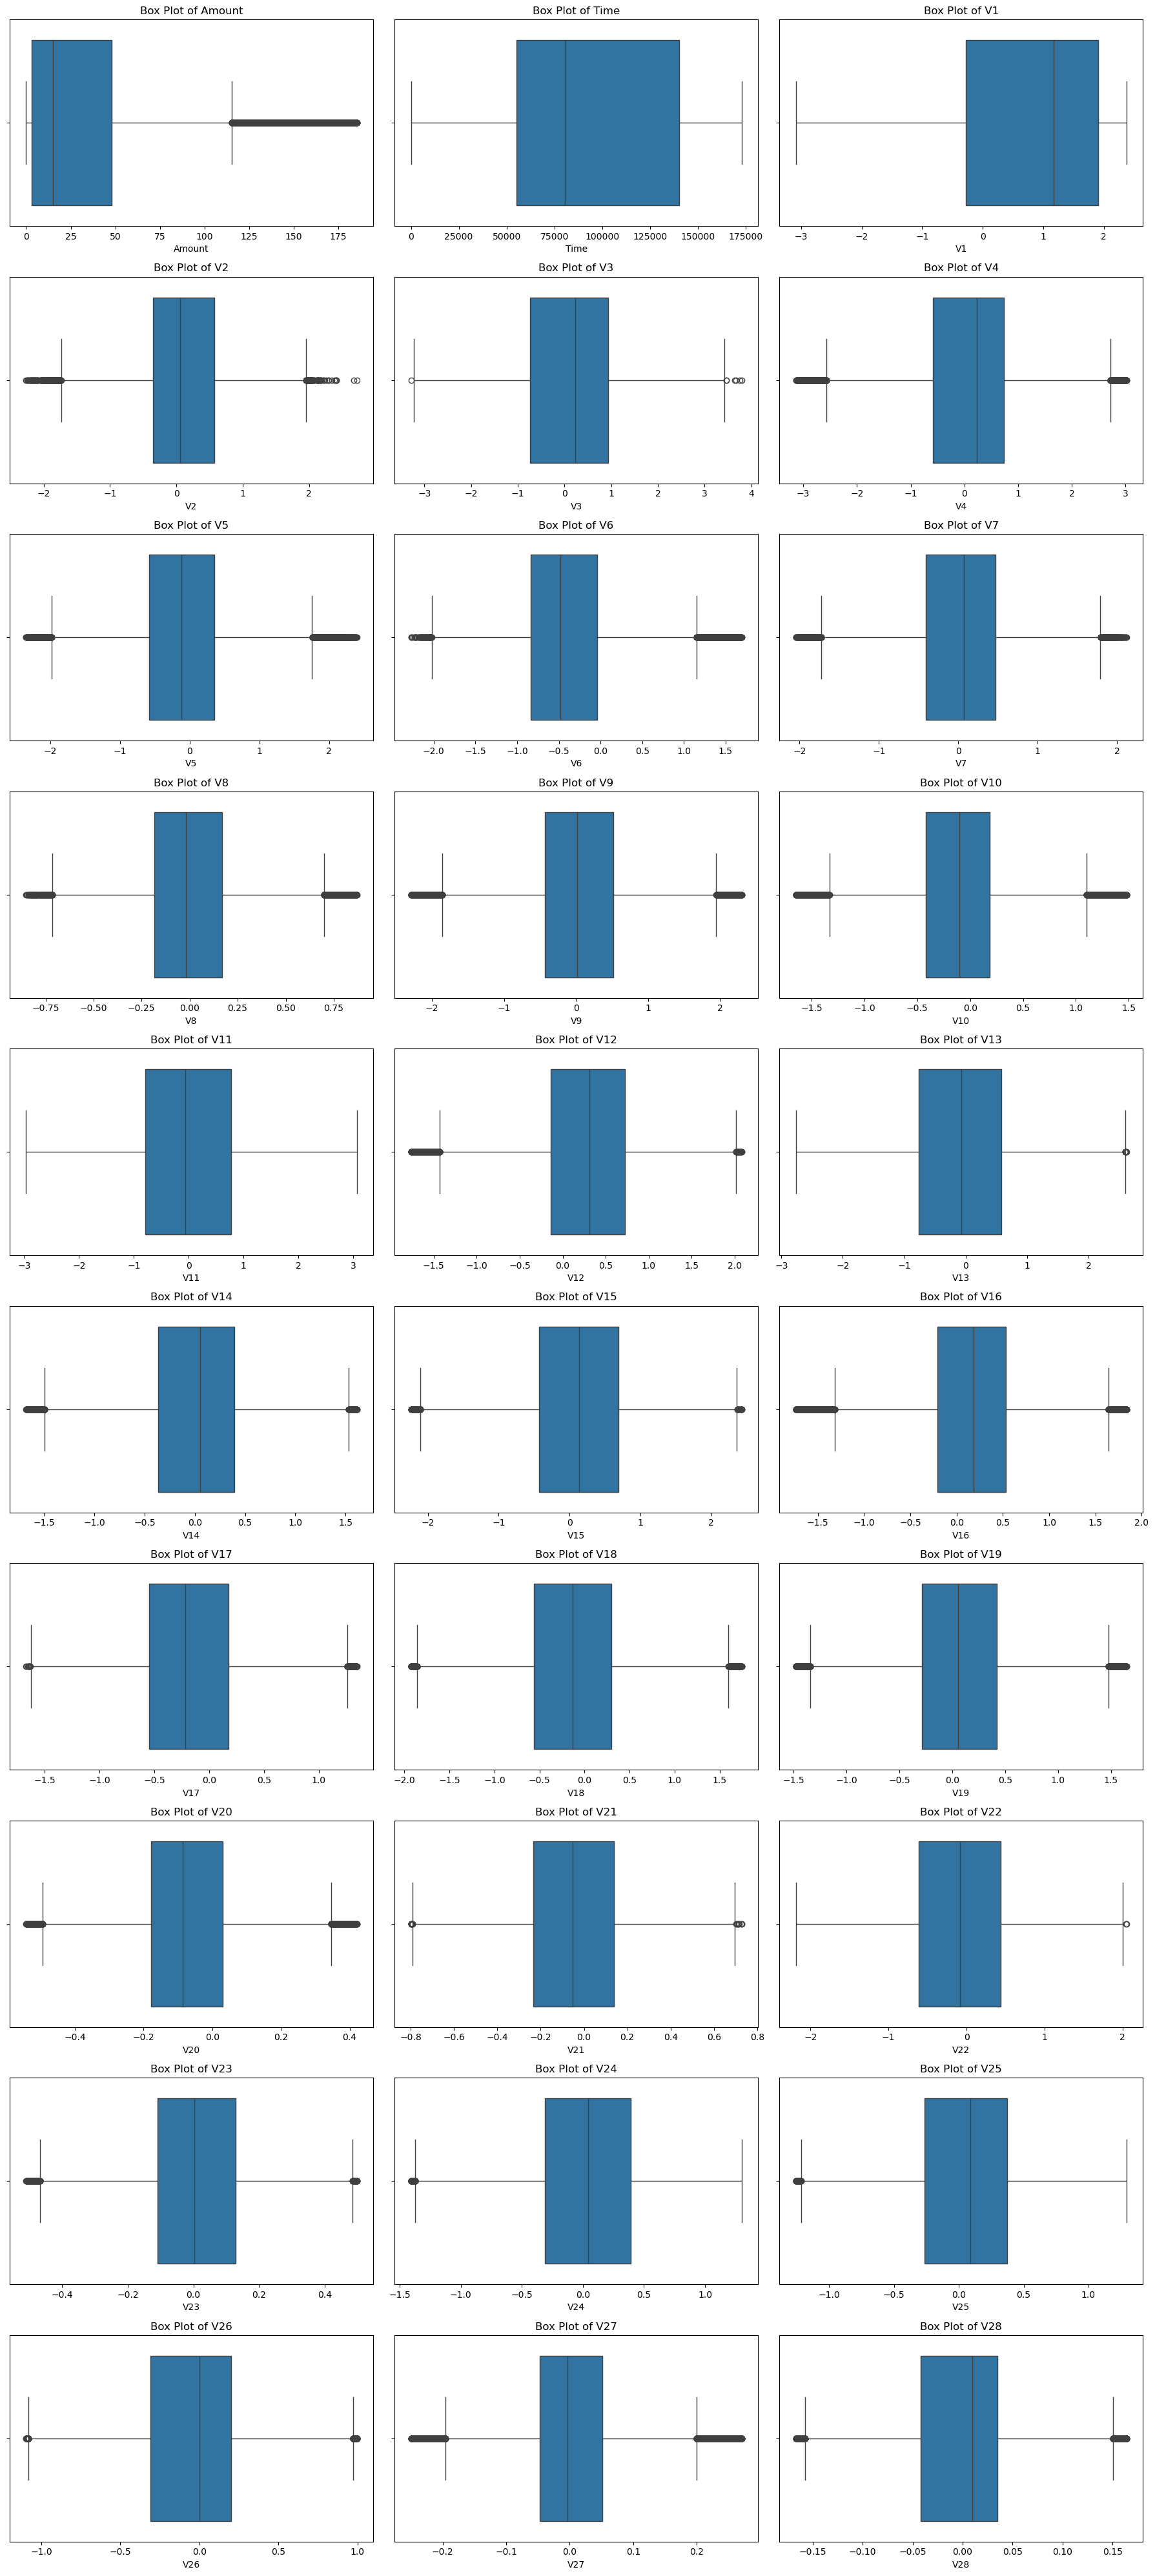

In [23]:


# Function to remove outliers and plot boxplots
def remove_outliers_and_plot(df, features):
    df_clean = df.copy()

    for feature in features:
        # Calculate Q1 and Q3
        Q1 = df_clean[feature].quantile(0.25)
        Q3 = df_clean[feature].quantile(0.75)
        IQR = Q3 - Q1

        # Outlier thresholds
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        # Remove outliers
        df_clean = df_clean[(df_clean[feature] >= lower_bound) & (df_clean[feature] <= upper_bound)]

    # Create subplots for the boxplots
    num_features = len(features)
    num_cols = 3
    num_rows = (num_features + num_cols - 1) // num_cols  # Calculate the number of rows needed

    fig, axes = plt.subplots(num_rows, num_cols, figsize=(18, 4 * num_rows))
    axes = axes.flatten()

    # Loop through each feature and create a boxplot
    for i, feature in enumerate(features):
        sns.boxplot(x=df_clean[feature], ax=axes[i])
        axes[i].set_title(f'Box Plot of {feature}', fontsize=12)

    # If there are any remaining empty subplots, remove them
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()  # Adjust layout for better spacing
    plt.show()

    return df_clean

# Check these features for outliers
features = ['Amount', 'Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
            'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
            'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28']

df_no_outliers = remove_outliers_and_plot(df_no_dup, features)


In [24]:
df_no_outliers.shape

(110453, 31)

In [25]:
df_no_outliers.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
5,2.0,-0.425966,0.960523,1.141109,-0.168252,0.420987,-0.029728,0.476201,0.260314,-0.568671,...,-0.208254,-0.559825,-0.026398,-0.371427,-0.232794,0.105915,0.253844,0.081080,3.67,0
6,4.0,1.229658,0.141004,0.045371,1.202613,0.191881,0.272708,-0.005159,0.081213,0.464960,...,-0.167716,-0.270710,-0.154104,-0.780055,0.750137,-0.257237,0.034507,0.005168,4.99,0
9,9.0,-0.338262,1.119593,1.044367,-0.222187,0.499361,-0.246761,0.651583,0.069539,-0.736727,...,-0.246914,-0.633753,-0.120794,-0.385050,-0.069733,0.094199,0.246219,0.083076,3.68,0


In [27]:
# Feature scaling: Scale the features using StandardScaler or MinMaxScaler to bring all features to a similar scale, which is essential for GAN training.

from sklearn.preprocessing import StandardScaler

# Scale "Amount" and "Time" and anonymized featuers
scaler = StandardScaler()
df_no_outliers[['Time', 'Amount']] = scaler.fit_transform(df_no_outliers[['Time','Amount']])

feature_columns = df_no_outliers.columns.drop('Class')
df_no_outliers[feature_columns] = scaler.fit_transform(df_no_outliers[feature_columns])

print(f"Data after scaling:\n{df_no_outliers.head()}")

Data after scaling:
       Time        V1        V2        V3        V4        V5        V6  \
0 -2.038193 -2.006071 -0.239486  2.103367  1.277895 -0.308276  1.478097   
1 -2.038193  0.313197  0.267902  0.079526  0.316850  0.257204  0.564283   
5 -2.038150 -1.157280  1.307391  0.911849 -0.320132  0.769634  0.652575   
6 -2.038107  0.347555  0.080554 -0.023900  1.096493  0.444396  1.159910   
9 -2.038000 -1.077564  1.545522  0.829232 -0.375867  0.880893  0.288502   

         V7        V8        V9  ...       V21       V22       V23       V24  \
0  0.320880  0.333270  0.414534  ...  0.091798  0.519556 -0.670252  0.099517   
1 -0.191156  0.283833 -0.381646  ... -0.791580 -0.871485  0.489579 -0.713102   
5  0.701371  0.920920 -0.784416  ... -0.716975 -0.751814 -0.209762 -0.776190   
6 -0.072726  0.269693  0.544622  ... -0.544371 -0.313007 -0.909215 -1.592513   
9  0.983411  0.227244 -1.000502  ... -0.881587 -0.864019 -0.726776 -0.803406   

        V25       V26       V27       V28    Amo

In [28]:
# Split the data into training and testing so we have separate datasets for training the GAN.

from sklearn.model_selection import train_test_split

X = df_no_outliers.drop(columns=['Class'])
y = df_no_outliers['Class']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set shape: {X_train.shape}")
print(f"Test set shape: {X_test.shape}")



Training set shape: (88362, 30)
Test set shape: (22091, 30)


In [73]:
print(X.shape, y.shape)

(110453, 30) (110453,)


In [29]:
# Implement a basic GAN using keras by creating a generator and discriminator

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LeakyReLU, BatchNormalization
from tensorflow.keras.optimizers import Adam

# Define the generator model
def build_generator(latent_dim):
    model = Sequential()
    model.add(Dense(128, input_dim=latent_dim))
    model.add(LeakyReLU(0.2))
    model.add(BatchNormalization())
    model.add(Dense(256))
    model.add(LeakyReLU(0.2))
    model.add(BatchNormalization())
    model.add(Dense(X_train.shape[1], activation='tanh'))
    return model

# Define the discriminator model
def build_discriminator():
    model = Sequential()
    model.add(Dense(256, input_dim=X_train.shape[1]))
    model.add(LeakyReLU(0.2))
    model.add(Dense(128))
    model.add(LeakyReLU(0.2))
    model.add(Dense(1, activation='sigmoid'))
    return model

# Compile the models
def compile_gan(generator, discriminator):
    discriminator.compile(loss='binary_crossentropy', optimizer=Adam(learning_rate=0.0002, beta_1=0.5), metrics=['accuracy'])
    gan = Sequential()
    gan.add(generator)
    gan.add(discriminator)
    gan.compile(loss='binary_crossentropy', optimizer=Adam(learning_rate=0.0002, beta_1=0.5))
    return gan

latent_dim = 100
generator = build_generator(latent_dim)
discriminator = build_discriminator()
gan = compile_gan(generator, discriminator)


In [30]:
# Train the GAN using early stopping (to save time)

from tensorflow.keras.callbacks import EarlyStopping

# Define the early stopping callback
early_stopping = EarlyStopping(monitor='loss', patience=1000, restore_best_weights=True)

def train_gan_with_early_stopping(gan, generator, discriminator, X_train, epochs=10000, batch_size=64):
    half_batch = batch_size // 2
    history = []

    for epoch in range(epochs):
        # Train discriminator
        idx = np.random.randint(0, X_train.shape[0], half_batch) #randomly select indices from real samples
        real_data = X_train.iloc[idx].values #extract real samples from the training data
        real_labels = np.ones((half_batch, 1)) #labels for real data are set to 1
        
        noise = np.random.normal(0, 1, (half_batch, latent_dim))
        fake_data = generator.predict(noise) #generate fake samples using the generator
        fake_labels = np.zeros((half_batch, 1)) #labels for fake data are set to 0
        
        d_loss_real = discriminator.train_on_batch(real_data, real_labels)
        d_loss_fake = discriminator.train_on_batch(fake_data, fake_labels)
        
        # Train generator
        noise = np.random.normal(0, 1, (batch_size, latent_dim))
        valid_labels = np.ones((batch_size, 1))
        g_loss = gan.train_on_batch(noise, valid_labels)
        
        # Append losses to history
        history.append({'epoch': epoch, 'd_loss': d_loss_real[0] + d_loss_fake[0], 'g_loss': g_loss})

        # Early stopping check
        if epoch % 1000 == 0:
            print(f"{epoch}/{epochs} [D loss: {d_loss_real[0] + d_loss_fake[0]} | D accuracy: {0.5 * (d_loss_real[1] + d_loss_fake[1])}] [G loss: {g_loss}]")
            # Check if early stopping condition is met
            if len(history) > 1 and (history[-1]['d_loss'] > min(h['d_loss'] for h in history[-10:])):
                print("Stopping early due to no improvement.")
                break

    return history

# Train the GAN with early stopping
history = train_gan_with_early_stopping(gan, generator, discriminator, X_train)


1/1 [==============================] - 0s 64ms/step
0/10000 [D loss: 1.4035531878471375 | D accuracy: 0.40625] [G loss: 0.640443742275238]
1/1 [==============================] - 0s 10ms/step
1000/10000 [D loss: 1.8287243694067001 | D accuracy: 0.5] [G loss: 0.2449914515018463]
Stopping early due to no improvement.


### GAN Training Result (early stopping):
D loss: Discriminator loss 1.8287 indicates the discriminator is finding it challenging to distinguish between real and generated publish_display_data<br>
D accuracy: 0..5 suggests that the discriminator is guessing the labels randomly. It is not learning effectively.<br>
G loss: Generator loss 0.2450, a lower G loss indicates that the generator is producing samples that are more likely to be mistaken as real by the discriminator.<br>

In [32]:
print("Shape of generated samples:", generated_samples.shape)

Shape of generated samples: (10, 30)


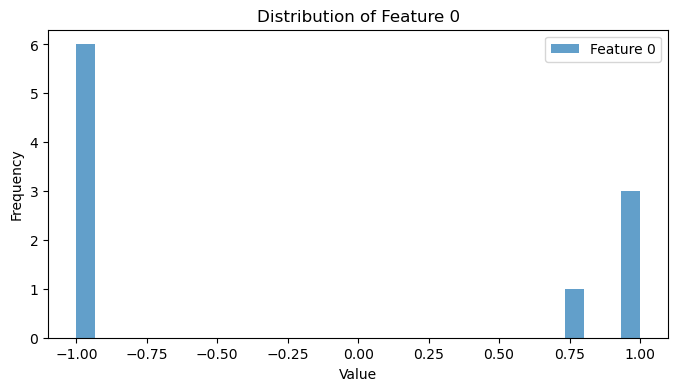

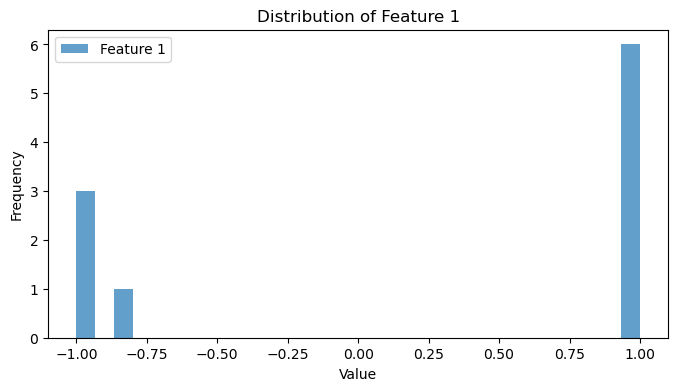

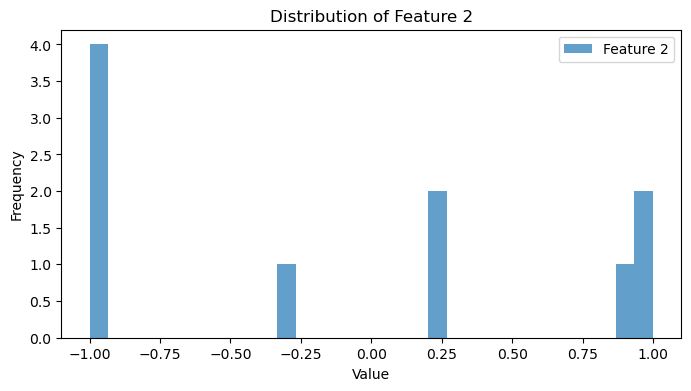

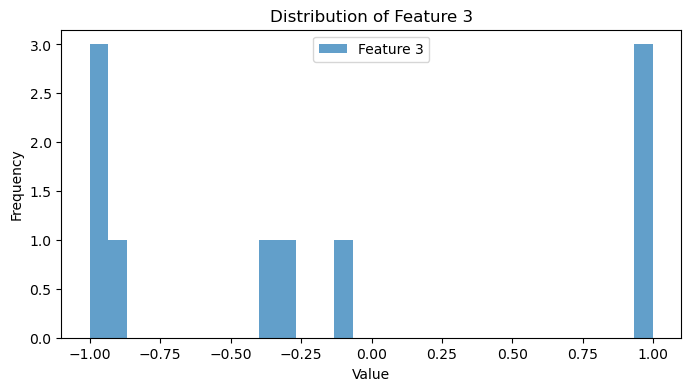

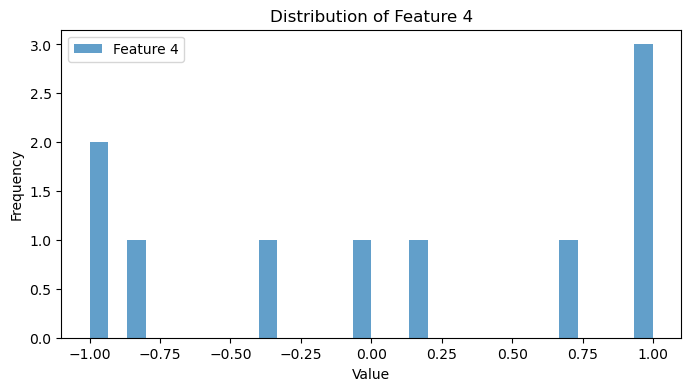

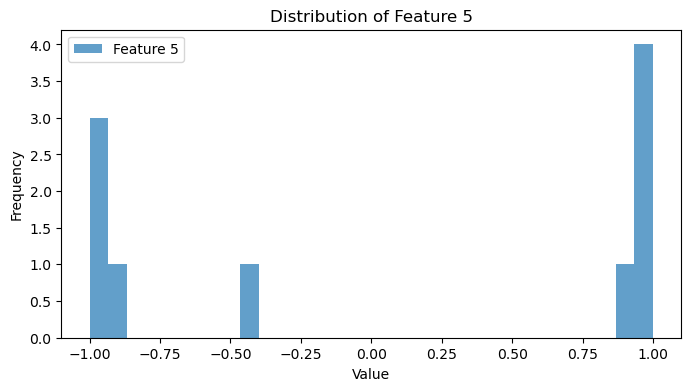

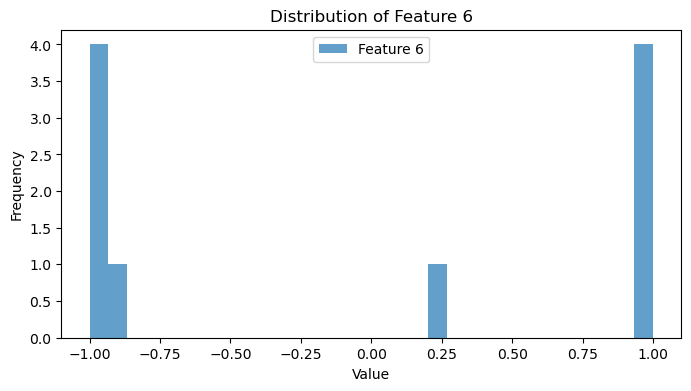

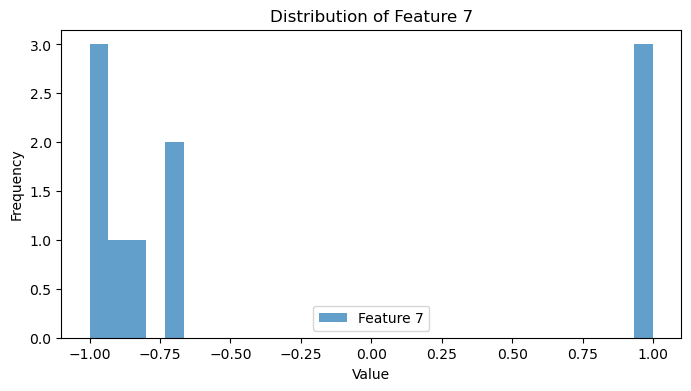

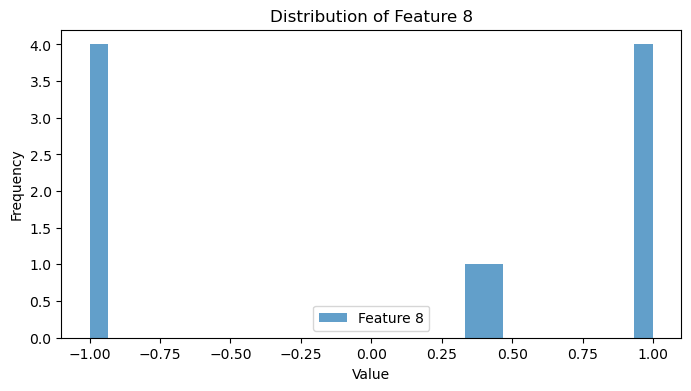

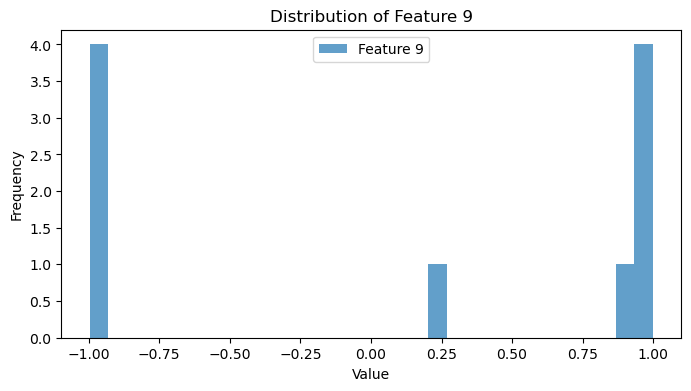

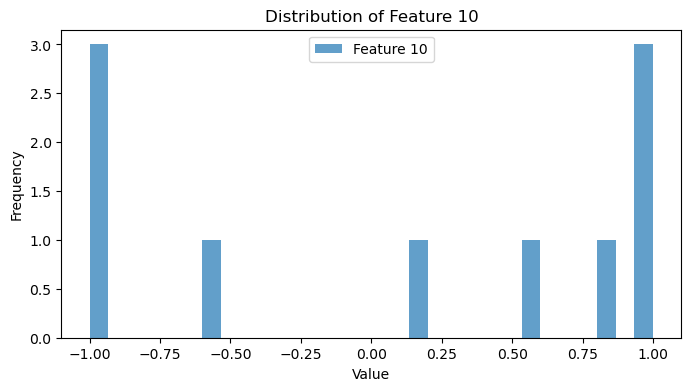

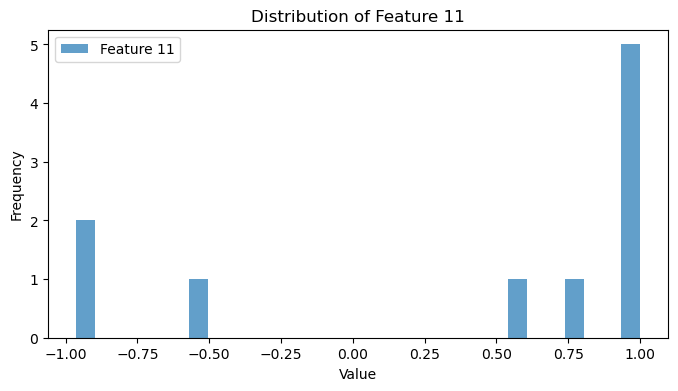

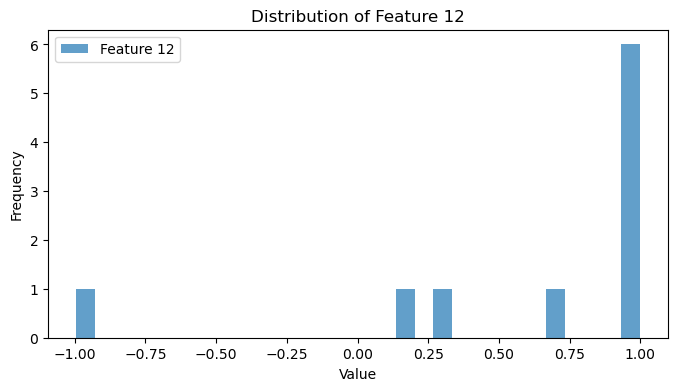

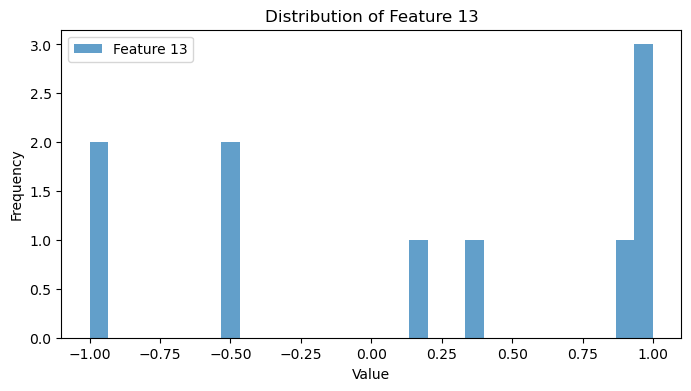

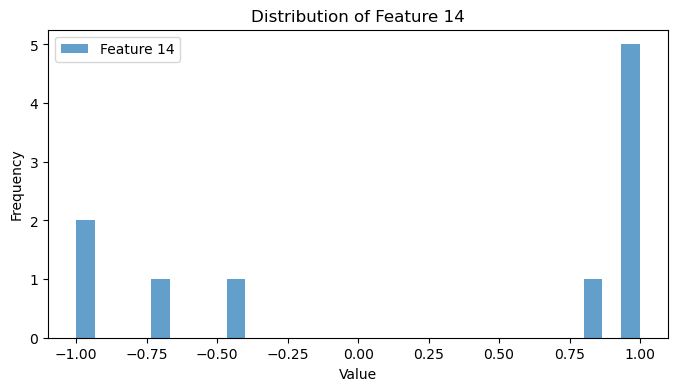

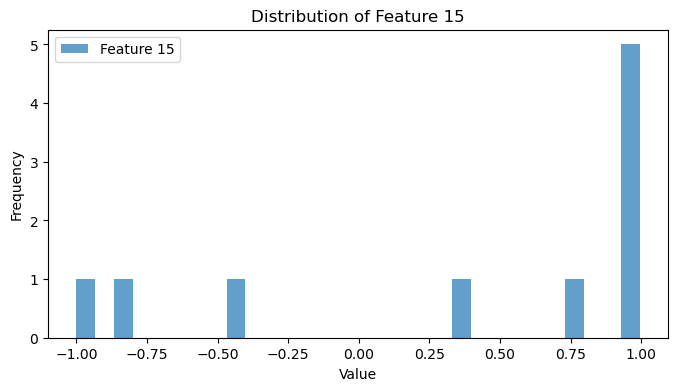

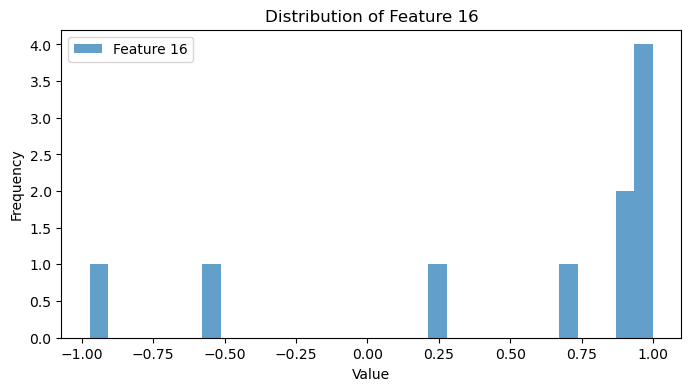

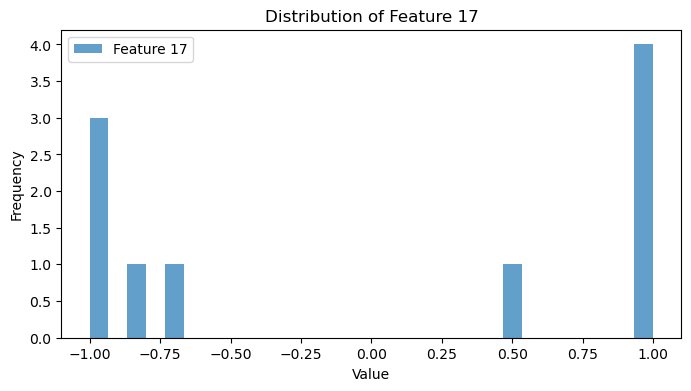

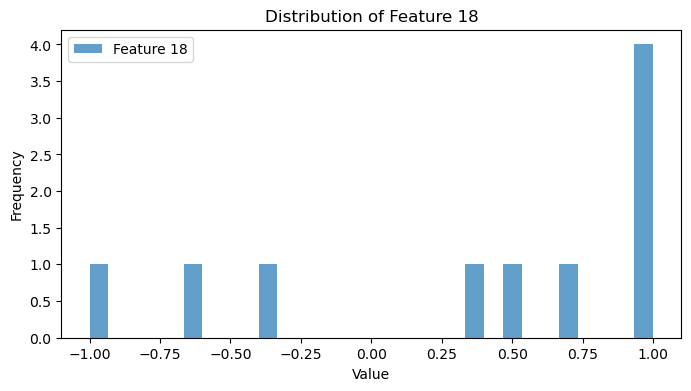

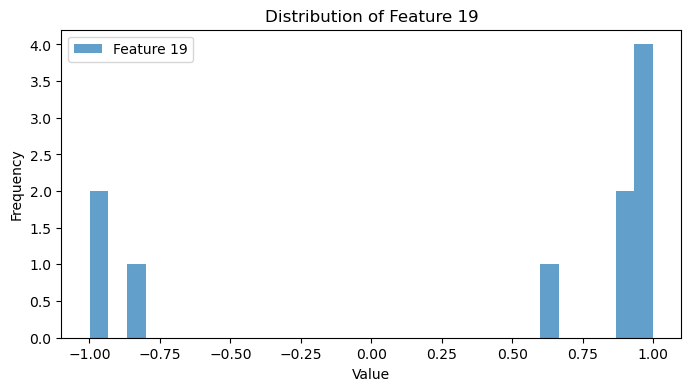

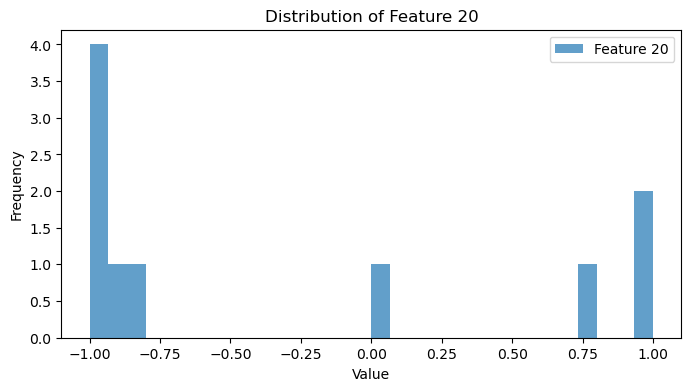

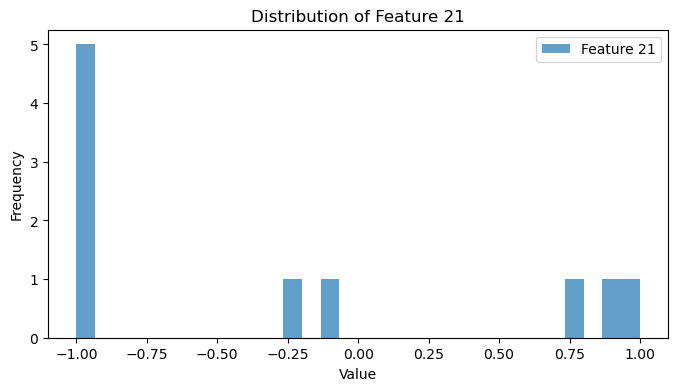

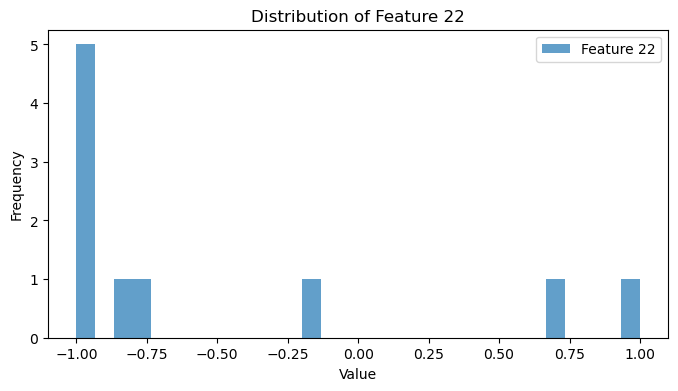

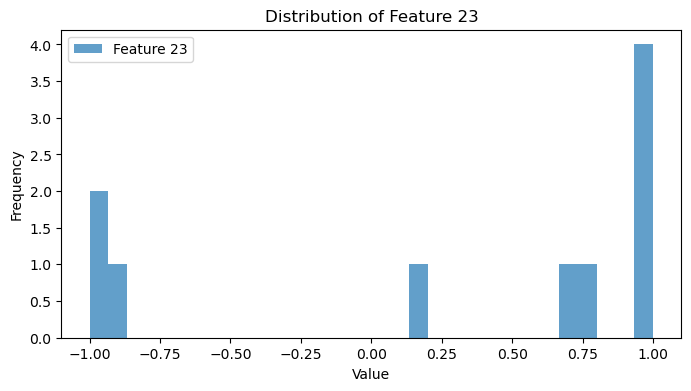

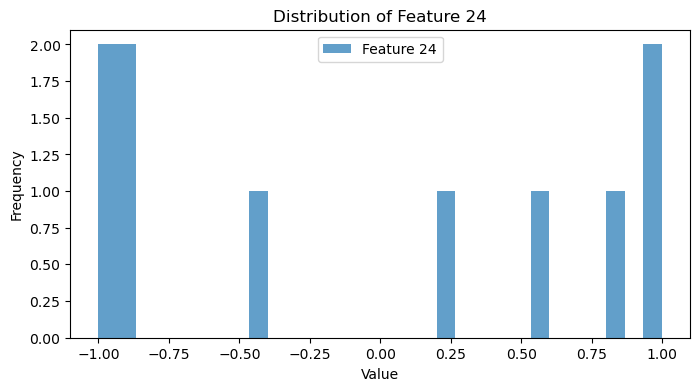

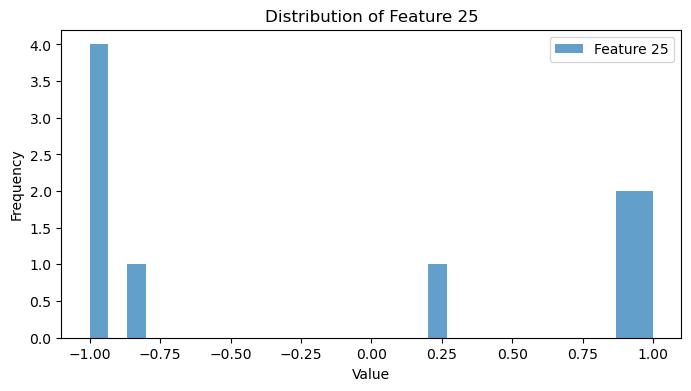

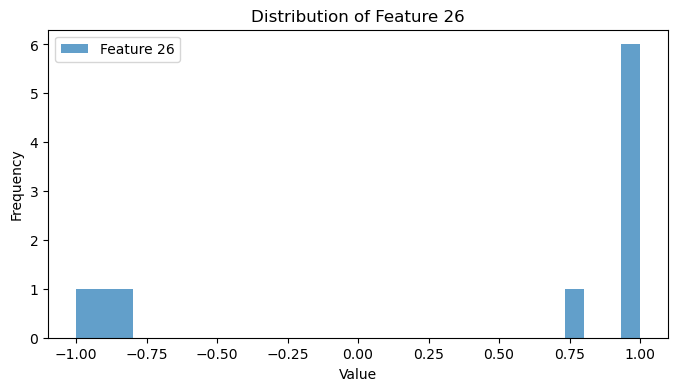

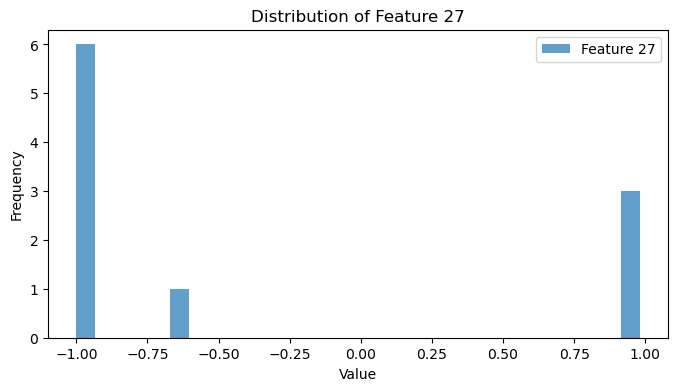

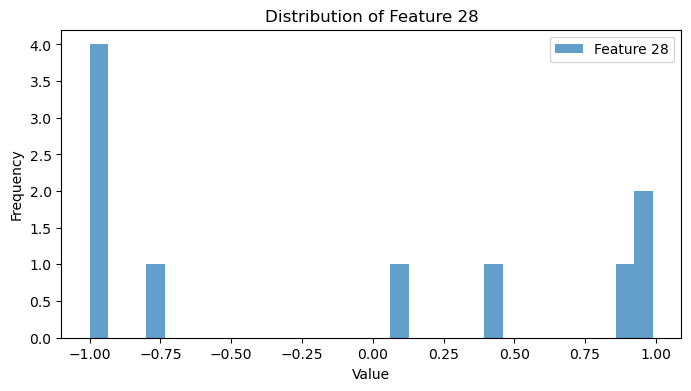

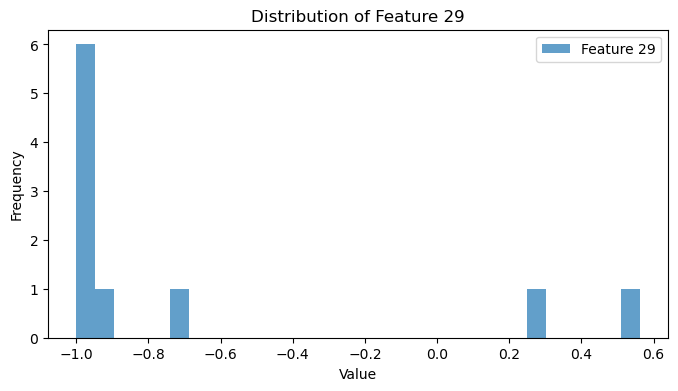

In [33]:


# Number of features
num_features = generated_samples.shape[1]

# Create a histogram for each feature
for i in range(num_features):
    plt.figure(figsize=(8, 4))
    plt.hist(generated_samples[:, i], bins=30, alpha=0.7, label=f'Feature {i}')
    plt.title(f'Distribution of Feature {i}')
    plt.xlabel('Value')
    plt.ylabel('Frequency')
    plt.legend()
    plt.show()



### Train GAN without early stopping

In [34]:
def train_gan(gan, generator, discriminator, X_train, epochs=10000, batch_size=64):
    half_batch = batch_size // 2
    history = []

    for epoch in range(epochs):
        # Train discriminator
        idx = np.random.randint(0, X_train.shape[0], half_batch)  # Randomly select indices from real samples
        real_data = X_train.iloc[idx].values  # Extract real samples from the training data
        real_labels = np.ones((half_batch, 1))  # Labels for real data are set to 1
        
        noise = np.random.normal(0, 1, (half_batch, latent_dim))
        fake_data = generator.predict(noise)  # Generate fake samples using the generator
        fake_labels = np.zeros((half_batch, 1))  # Labels for fake data are set to 0
        
        d_loss_real = discriminator.train_on_batch(real_data, real_labels)
        d_loss_fake = discriminator.train_on_batch(fake_data, fake_labels)
        
        # Train generator
        noise = np.random.normal(0, 1, (batch_size, latent_dim))
        valid_labels = np.ones((batch_size, 1))
        g_loss = gan.train_on_batch(noise, valid_labels)
        
        # Append losses to history
        history.append({'epoch': epoch, 'd_loss': d_loss_real[0] + d_loss_fake[0], 'g_loss': g_loss})

        # Print progress
        if epoch % 1000 == 0:
            print(f"{epoch}/{epochs} [D loss: {d_loss_real[0] + d_loss_fake[0]} | D accuracy: {0.5 * (d_loss_real[1] + d_loss_fake[1])}] [G loss: {g_loss}]")

    return history

# Train the GAN without early stopping
history = train_gan(gan, generator, discriminator, X_train)


1/1 [==============================] - 0s 11ms/step
0/10000 [D loss: 1.7614974528551102 | D accuracy: 0.5] [G loss: 0.25301194190979004]
1/1 [==============================] - 0s 10ms/step
1000/10000 [D loss: 1.7128031253814697 | D accuracy: 0.5] [G loss: 0.25864318013191223]
1/1 [==============================] - 0s 10ms/step
2000/10000 [D loss: 1.7106476426124573 | D accuracy: 0.5] [G loss: 0.26125848293304443]
1/1 [==============================] - 0s 12ms/step
3000/10000 [D loss: 1.7106672525405884 | D accuracy: 0.5] [G loss: 0.25112348794937134]
1/1 [==============================] - 0s 9ms/step
4000/10000 [D loss: 1.7069836556911469 | D accuracy: 0.5] [G loss: 0.27171075344085693]
1/1 [==============================] - 0s 9ms/step
5000/10000 [D loss: 1.741497963666916 | D accuracy: 0.5] [G loss: 0.27634066343307495]
1/1 [==============================] - 0s 10ms/step
6000/10000 [D loss: 1.6747106909751892 | D accuracy: 0.5] [G loss: 0.31297096610069275]
1/1 [=====================

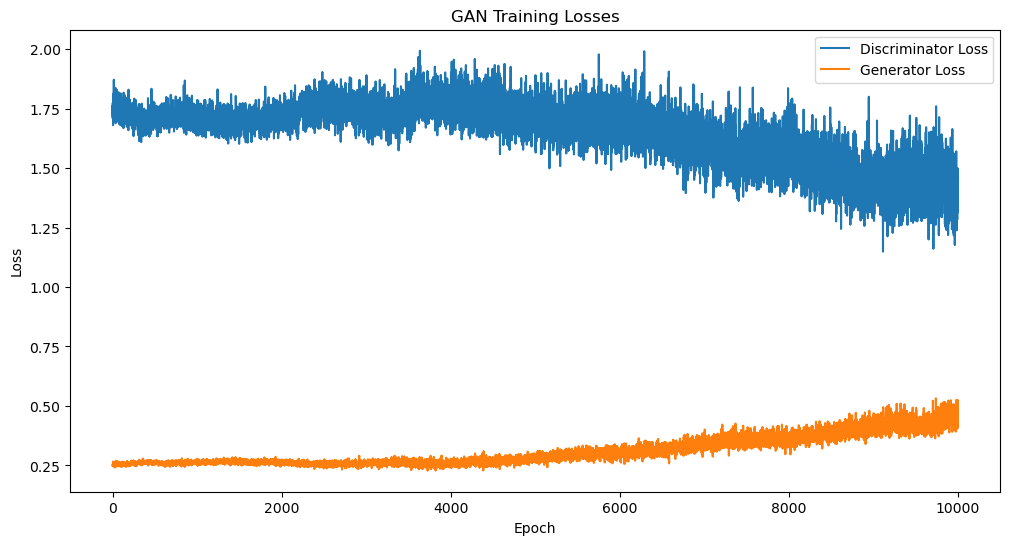

In [35]:
# visualize training loss

# Extract loss values from history
epochs = [entry['epoch'] for entry in history]
d_losses = [entry['d_loss'] for entry in history]
g_losses = [entry['g_loss'] for entry in history]

# Plot losses
plt.figure(figsize=(12, 6))
plt.plot(epochs, d_losses, label='Discriminator Loss')
plt.plot(epochs, g_losses, label='Generator Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('GAN Training Losses')
plt.legend()
plt.show()


In [36]:
print("Generator Summary:")
generator.summary()

print("\nDiscriminator Summary:")
discriminator.summary()


Generator Summary:
Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 128)               12928     
                                                                 
 leaky_re_lu (LeakyReLU)     (None, 128)               0         
                                                                 
 batch_normalization (Batch  (None, 128)               512       
 Normalization)                                                  
                                                                 
 dense_1 (Dense)             (None, 256)               33024     
                                                                 
 leaky_re_lu_1 (LeakyReLU)   (None, 256)               0         
                                                                 
 batch_normalization_1 (Bat  (None, 256)               1024      
 chNormalization)                    

### with early stopping:
[D loss: 1.4035531878471375 | D accuracy: 0.40625] [G loss: 0.640443742275238]

### without early stopping:
[D loss: 1.7614974528551102 | D accuracy: 0.5] [G loss: 0.25301194190979004]

In [42]:
y_train = y_train.values
y_train = y_train.reshape(-1, 1)


In [83]:
# IN PROGRESS, Tried to use conditional GAN but getting some errors. 
# Create the cGAN class

from tensorflow.keras.layers import Input, Dense, LeakyReLU, Dropout, Embedding, Flatten, multiply
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.optimizers import Adam
import numpy as np
import tensorflow.keras.backend as K
from sklearn.utils import shuffle

class cGAN():
    def __init__(self):
        self.latent_dim = 32
        self.out_shape = 29
        self.num_classes = 2
        self.clip_value = 0.01
        optimizer = Adam(0.0002, 0.5)

        # build discriminator
        self.discriminator = self.build_discriminator()
        self.discriminator.compile(loss=['binary_crossentropy'],
                                   optimizer=optimizer,
                                   metrics=['accuracy'])

        # build generator
        self.generator = self.build_generator()

        # generating new data samples
        noise = Input(shape=(self.latent_dim,))
        label = Input(shape=(1,))
        gen_samples = self.generator([noise, label])

        self.discriminator.trainable = False

        # passing gen samples through disc. 
        valid = self.discriminator([gen_samples, label])

        # combining both models
        self.combined = Model([noise, label], valid)
        self.combined.compile(loss=['binary_crossentropy'],
                              optimizer=optimizer,
                             metrics=['accuracy'])
        self.combined.summary()

    def wasserstein_loss(self, y_true, y_pred):
        return K.mean(y_true * y_pred)

    def build_generator(self):
        init = RandomNormal(mean=0.0, stddev=0.02)
        model = Sequential()

        model.add(Dense(128, input_dim=self.latent_dim))
        model.add(LeakyReLU(alpha=0.2))
        model.add(BatchNormalization(momentum=0.8))

        model.add(Dense(256))
        model.add(LeakyReLU(alpha=0.2))
        model.add(BatchNormalization(momentum=0.8))

        model.add(Dense(512))
        model.add(LeakyReLU(alpha=0.2))
        model.add(BatchNormalization(momentum=0.8))

        model.add(Dense(self.out_shape, activation='tanh'))
        model.summary()

        noise = Input(shape=(self.latent_dim,))
        label = Input(shape=(1,), dtype='int32')
        label_embedding = Flatten()(Embedding(self.num_classes, self.latent_dim)(label))

        model_input = multiply([noise, label_embedding])
        gen_sample = model(model_input)

        return Model([noise, label], gen_sample, name="Generator")

    
    def build_discriminator(self):
        init = RandomNormal(mean=0.0, stddev=0.02)
        model = Sequential()

        model.add(Dense(512, input_dim=self.out_shape, kernel_initializer=init))
        model.add(LeakyReLU(alpha=0.2))

        model.add(Dense(256, kernel_initializer=init))
        model.add(LeakyReLU(alpha=0.2))
        model.add(Dropout(0.4))

        model.add(Dense(128, kernel_initializer=init))
        model.add(LeakyReLU(alpha=0.2))
        model.add(Dropout(0.4))

        model.add(Dense(1, activation='sigmoid'))
        model.summary()

        gen_sample = Input(shape=(self.out_shape,))
        label = Input(shape=(1,), dtype='int32')
        label_embedding = Flatten()(Embedding(self.num_classes, self.out_shape)(label))

        model_input = multiply([gen_sample, label_embedding])
        validity = model(model_input)

        return Model(inputs=[gen_sample, label], outputs=validity, name="Discriminator")


    def train(self, X_train, y_train, pos_index, neg_index, epochs, batch_size=32, sample_interval=50):

        # Adversarial ground truths
        valid = np.ones((batch_size, 1))
        fake = np.zeros((batch_size, 1))

        for epoch in range(epochs):
            print(f"Epoch {epoch + 1}/{epochs}")  # Debug statement

            idx1 = np.random.choice(pos_index, 8)
            idx0 = np.random.choice(neg_index, batch_size-8)
            idx = np.concatenate((idx1, idx0))


            
            samples, labels = X_train[idx], y_train[idx]
            samples, labels = shuffle(samples, labels)
            noise = np.random.normal(0, 1, (batch_size, self.latent_dim))
            gen_samples = self.generator.predict([noise, labels])

            if epoch < epochs // 1.5:
                valid_smooth = (valid + 0.1) - (np.random.random(valid.shape) * 0.1)
                fake_smooth = (fake - 0.1) + (np.random.random(fake.shape) * 0.1)
            else:
                valid_smooth = valid
                fake_smooth = fake

            self.discriminator.trainable = True
            d_loss_real = self.discriminator.train_on_batch([samples, labels], valid_smooth)
            d_loss_fake = self.discriminator.train_on_batch([gen_samples, labels], fake_smooth)
            d_loss = 0.5 * np.add(d_loss_real, d_loss_fake)

            self.discriminator.trainable = False
            sampled_labels = np.random.randint(0, 2, batch_size).reshape(-1, 1)
            g_loss = self.combined.train_on_batch([noise, sampled_labels], valid)

            if (epoch + 1) % sample_interval == 0:
                print(f"{epoch + 1} [D loss: {d_loss[0]}, acc.: {100 * d_loss[1]}] [G loss: {g_loss}]")


In [48]:
pos_index = np.where(y_train == 1)[0]  # Indices where label is 1 (positive class)
neg_index = np.where(y_train == 0)[0]  # Indices where label is 0 (negative class)


In [77]:
y_train.shape

(88362, 1)

In [76]:
X_train.shape

(88362, 30)

In [64]:
y_train = y_train.astype(np.int32)
print(f"y_train dtype after conversion: {y_train.dtype}")


y_train dtype after conversion: int32


In [78]:
def train(self, X_train, y_train, pos_index, neg_index, epochs, batch_size=32, sample_interval=50):
    # Adversarial ground truths
    valid = np.ones((batch_size, 1))
    fake = np.zeros((batch_size, 1))

    for epoch in range(epochs):
        print(f"Epoch {epoch + 1}/{epochs}")  # Debug statement

        # Generate indices
        idx1 = np.random.choice(pos_index, 8)
        idx0 = np.random.choice(neg_index, batch_size - 8)
        idx = np.concatenate((idx1, idx0))

        # Debug: print idx and its length
        print(f"Selected indices (length {len(idx)}): {idx}")

        try:
            # Ensure idx is used correctly
            samples = X_train.iloc[idx].values
            labels = y_train.iloc[idx].values
            print(f"Samples shape: {samples.shape}")  # Debug print
            print(f"Labels shape: {labels.shape}")  # Debug print
        except Exception as e:
            print(f"Error with idx or data extraction: {e}")
            continue

        samples, labels = shuffle(samples, labels)
        noise = np.random.normal(0, 1, (batch_size, self.latent_dim))
        gen_samples = self.generator.predict([noise, labels])

        if epoch < epochs // 1.5:
            valid_smooth = (valid + 0.1) - (np.random.random(valid.shape) * 0.1)
            fake_smooth = (fake - 0.1) + (np.random.random(fake.shape) * 0.1)
        else:
            valid_smooth = valid
            fake_smooth = fake

        self.discriminator.trainable = True
        d_loss_real = self.discriminator.train_on_batch([samples, labels], valid_smooth)
        d_loss_fake = self.discriminator.train_on_batch([gen_samples, labels], fake_smooth)
        d_loss = 0.5 * np.add(d_loss_real, d_loss_fake)

        self.discriminator.trainable = False
        sampled_labels = np.random.randint(0, 2, batch_size).reshape(-1, 1)
        g_loss = self.combined.train_on_batch([noise, sampled_labels], valid)

        if (epoch + 1) % sample_interval == 0:
            print(f"{epoch + 1} [D loss: {d_loss[0]}, acc.: {100 * d_loss[1]}] [G loss: {g_loss}]")


In [84]:
# Instantiate the cGAN class
cgan = cGAN()

# Start training
epochs = 2000
batch_size = 32
sample_interval = 50

cgan.train(X_train, y_train, pos_index, neg_index, epochs=epochs, batch_size=batch_size, sample_interval=sample_interval)


Model: "sequential_19"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_70 (Dense)            (None, 512)               15360     
                                                                 
 leaky_re_lu_52 (LeakyReLU)  (None, 512)               0         
                                                                 
 dense_71 (Dense)            (None, 256)               131328    
                                                                 
 leaky_re_lu_53 (LeakyReLU)  (None, 256)               0         
                                                                 
 dropout_16 (Dropout)        (None, 256)               0         
                                                                 
 dense_72 (Dense)            (None, 128)               32896     
                                                                 
 leaky_re_lu_54 (LeakyReLU)  (None, 128)             

KeyError: "None of [Index([50487, 26261, 36531, 48621, 54911, 23677, 85416,  7445, 40973, 83303,\n       88326, 27276, 46552, 25775, 58326, 47142, 12622, 30637, 79160, 41696,\n       30190, 72094, 75930, 19118, 17354, 51978, 79495, 31282, 12800, 17862,\n       52582, 31670],\n      dtype='int64')] are in the [columns]"